# 📚  Phishing Email Detection using BERT - Project Notebook

## 📌 Table of Contents

In [1]:
import sys
print(sys.executable)


C:\ProgramData\anaconda3\python.exe


In [2]:
!{sys.executable} -m pip install transformers datasets


Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import re
 

#libraries for data explore
import seaborn as sns
import matplotlib.pyplot as plt

#libraries for Model training and evaluation
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
# Example: Load a CSV dataset
df = pd.read_csv("phishing_email.csv")
df.shape


(82486, 2)

In [5]:
# Randomly sample 15,000 rows from the full dataset
df = df.sample(n=15000, random_state=42).reset_index(drop=True)
print(df.head())

                                       text_combined  label
0  endangered languages workshop foundation endan...      0
1  claretta claretta_bordersfusemailcom cialis wo...      1
2  roger upole schkeramsncom kyle rickey wrote im...      0
3  barclays customer service testlightworldcojp d...      1
4  gmm 09 nov 2001 please find attached global ma...      0


In [6]:
# Remove nulls
df.dropna(inplace=True)

df['label'] = df['label'].astype(int)

# Lowercasing only
def clean_text(text):
    return text.lower()

df['text_combined'] = df['text_combined'].apply(clean_text)

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  15000 non-null  object
 1   label          15000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 234.5+ KB
None


In [8]:
df.shape

(15000, 2)

In [9]:
df.tail()

,text_combined,label
14995,winning notification dalobica lotto bv interna...,1
14996,become happy performance girlfriend loves resu...,1
14997,looks good obviously close originally suggest...,0
14998,cnn alerts frakte_1973emmeffenet cnn alerts cu...,1
14999,danny graham ingridchianghadleybuytaertnet syo...,1


# Explore the dataset

## Plot Class Distribution

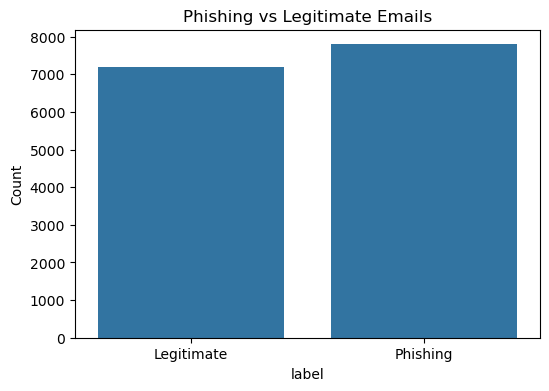

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label') # counts the number of occurrences of each unique value in a column
plt.title('Phishing vs Legitimate Emails')
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.ylabel('Count')
plt.show()

### Email/Text special character Length Distribution by Class

#### This graph is a boxplot comparing the number of special characters used in legitimate vs phishing emails.

#### Special characters: ! @ # $ % ^ & * ( ) _ + = { } [ ] : ; " ' < > / ? , . ~ etc.

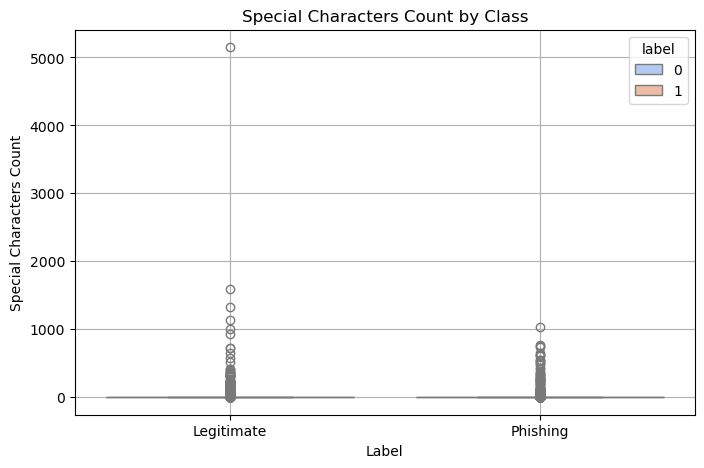

In [11]:
df['special_chars'] = df['text_combined'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='special_chars', data=df, hue='label', palette='coolwarm', dodge=False)

plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.title('Special Characters Count by Class')
plt.xlabel('Label')
plt.ylabel('Special Characters Count')
plt.grid(True)
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


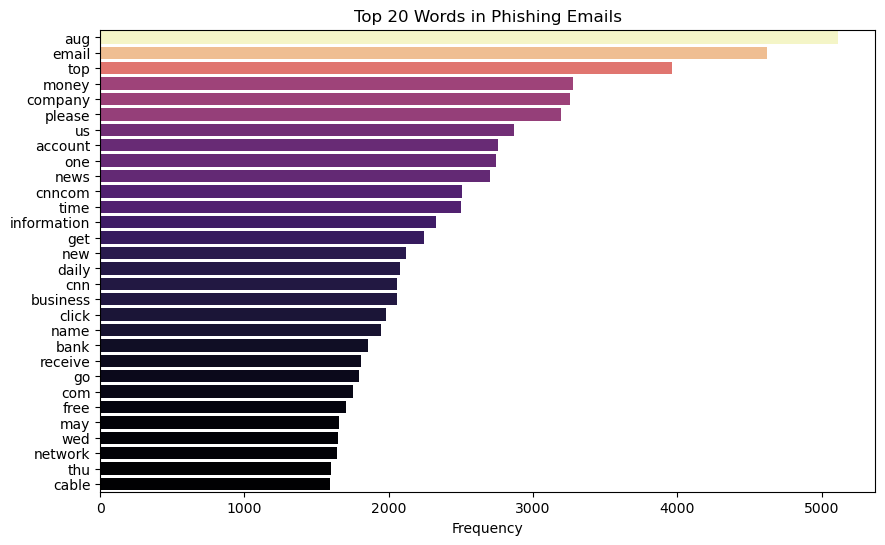

In [12]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


stop_words = set(stopwords.words('english'))  #e.g., "the", "is", "and"

# Combine all phishing emails: Joins all texts into one string → converts to lowercase → splits into words
phishing_words = ' '.join(df[df['label']==1]['text_combined']).lower().split() #Selects only phishing emails (where label == 1)

filtered_words = [word for word in phishing_words if word.isalpha() and word not in stop_words] #Alphabetic words (removes numbers, punctuation)

word_freq = Counter(filtered_words).most_common(30)

# Barplot of top words
words, counts = zip(*word_freq)  #Unpacks the 20 most common word–count pairs into two separate lists: words and counts
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words),hue =list(counts), palette='magma',legend=False)
plt.title('Top 20 Words in Phishing Emails')
plt.xlabel('Frequency')
plt.show()

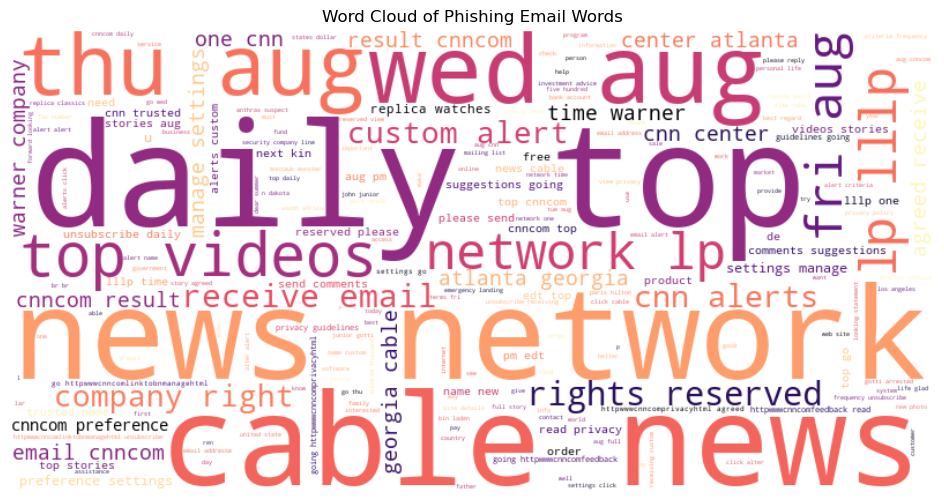

In [13]:
from wordcloud import WordCloud

# Join all filtered phishing words into a single string
wordcloud_text = ' '.join(filtered_words)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Phishing Email Words')
plt.show()

# Split the Dataset in training , validation and test

In [14]:
from sklearn.model_selection import train_test_split

# 1. First, split out 20% test data

train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(df['text_combined'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

# 2. Then split remaining 80% into 70% train and 10% val

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,  # 10% of total = 12.5% of the remaining 80%
    random_state=42, stratify=train_val_labels
)

## Tokenization using BERT Tokenizer

#### These encodings are the tokenized versions of your input texts, structured in a way that BERT can understand

In [15]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the datasets
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

In [16]:
print(train_encodings['input_ids'][0])          # View input IDs of the first text
print(train_encodings['attention_mask'][0]) 

[101, 17264, 7027, 2373, 3001, 3204, 3283, 2218, 3116, 5395, 3288, 2362, 3001, 3136, 3293, 2111, 3625, 12697, 2311, 17264, 7027, 3001, 2763, 3174, 2111, 2164, 7014, 2566, 12624, 4938, 2154, 7113, 7014, 10439, 14511, 2080, 3960, 2534, 8886, 17891, 6746, 6927, 3902, 3762, 6754, 24185, 21007, 2063, 7369, 2014, 19333, 6264, 6606, 3889, 14085, 5076, 20105, 16215, 6072, 2050, 5297, 11623, 2928, 27078, 8512, 6519, 10524, 2116, 2048, 17817, 4484, 3116, 2034, 3154, 9129, 2111, 2551, 9033, 10483, 7014, 2177, 3225, 2831, 4938, 2177, 2609, 6337, 2136, 3931, 20105, 9352, 26351, 2014, 19333, 25212, 2015, 4372, 2050, 3043, 2264, 4372, 2050, 2225, 4372, 2050, 3872, 2968, 19387, 2080, 7617, 2111, 3331, 2028, 2178, 2117, 3154, 6343, 2699, 4949, 4072, 4972, 4906, 2362, 13487, 6927, 3902, 3762, 28762, 8925, 6746, 5247, 3204, 3331, 2177, 5059, 3861, 3001, 2499, 4906, 2362, 2716, 3232, 2111, 9669, 5397, 6509, 2622, 2373, 8400, 8312, 5491, 9556, 2052, 8627, 2298, 5530, 2340, 2321, 7680, 7849, 4697, 3314, 114

### Convert to HuggingFace Dataset

In [17]:
import torch

class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
        
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)

### Load Pretrained BERT for Classification

In [18]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Define Evaluation Metrics

In [19]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

### Training Arguments

In [20]:
pip install --upgrade transformers accelerate


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [21]:
import transformers
print(transformers.__version__)


5.12.1


In [22]:
!pip install --upgrade transformers accelerate
!pip show transformers


Defaulting to user installation because normal site-packages is not writeable
Name: transformers
Version: 5.12.1
Summary: Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, and multimodal models, for both inference and training.
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: C:\Users\hp\AppData\Roaming\Python\Python313\site-packages
Requires: huggingface-hub, numpy, packaging, pyyaml, regex, safetensors, tokenizers, tqdm, typer
Required-by: 


In [23]:
# !pip show transformers
# !pip show accelerate
# !pip show transformers
# !pip install --upgrade transformers accelerate
# import transformers
# print(transformers.__version__)
!pip install "accelerate>=1.1.0" --upgrade
!pip install transformers[torch] --upgrade
import accelerate
print(accelerate.__version__)  # 1.1.0 ya usse upar hona chahiye

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
1.14.0


In [24]:
import sys
print(sys.version)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [25]:
from transformers import TrainingArguments
print("TrainingArguments imported successfully!")


TrainingArguments imported successfully!


In [26]:
from transformers import TrainingArguments


In [27]:
import os
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    optim="adamw_torch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

In [30]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
from transformers import Trainer, DataCollatorWithPadding

from transformers import Trainer, DataCollatorWithPadding

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)




Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer.train()

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## Plot Accuracy and Loss vs Epoch

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss = [entry['loss'] for entry in log_history if 'loss' in entry]
eval_loss = [entry['eval_loss'] for entry in log_history if 'eval_loss' in entry]
eval_acc  = [entry['eval_accuracy'] for entry in log_history if 'eval_accuracy' in entry]
epochs = list(range(1, len(eval_loss)+1))

plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, eval_loss, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, eval_acc, marker='o', color='green', label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()


## Save the Final Model & Tokenizer

In [7]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Pretrained model और tokenizer load करो
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# अब save करो
model.save_pretrained(r"E:\BCA [ DS & AI ]\PROJECT'S\PYTHON\Detect AIGenerated Phishing Emails with BERT\Dataset")
tokenizer.save_pretrained(r"E:\BCA [ DS & AI ]\PROJECT'S\PYTHON\Detect AIGenerated Phishing Emails with BERT\Dataset")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

("E:\\BCA [ DS & AI ]\\PROJECT'S\\PYTHON\\Detect AIGenerated Phishing Emails with BERT\\Dataset\\tokenizer_config.json",
 "E:\\BCA [ DS & AI ]\\PROJECT'S\\PYTHON\\Detect AIGenerated Phishing Emails with BERT\\Dataset\\tokenizer.json")

In [8]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
model.save_pretrained(r"E:\BCA [ DS & AI ]\PROJECT'S\PYTHON\Detect AIGenerated Phishing Emails with BERT\Dataset")
tokenizer.save_pretrained(r"E:\BCA [ DS & AI ]\PROJECT'S\PYTHON\Detect AIGenerated Phishing Emails with BERT\Dataset")



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

("E:\\BCA [ DS & AI ]\\PROJECT'S\\PYTHON\\Detect AIGenerated Phishing Emails with BERT\\Dataset\\tokenizer_config.json",
 "E:\\BCA [ DS & AI ]\\PROJECT'S\\PYTHON\\Detect AIGenerated Phishing Emails with BERT\\Dataset\\tokenizer.json")

In [10]:
from transformers import BertForSequenceClassification, BertTokenizer

model = BertForSequenceClassification.from_pretrained(
    r"E:\BCA [ DS & AI ]\PROJECT'S\PYTHON\Detect AIGenerated Phishing Emails with BERT\Dataset",
    local_files_only=True
)
tokenizer = BertTokenizer.from_pretrained(
    r"E:\BCA [ DS & AI ]\PROJECT'S\PYTHON\Detect AIGenerated Phishing Emails with BERT\Dataset",
    local_files_only=True
)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [12]:
test_texts = ["यह एक सुरक्षित ईमेल है।", "यहाँ क्लिक करो और इनाम पाओ!"]

test_encodings = tokenizer(test_texts, truncation=True, padding=True, return_tensors="pt")
outputs = model(**test_encodings)
predictions = outputs.logits.argmax(dim=1)

print("Predictions:", predictions)


Predictions: tensor([0, 0])


## Test the model

### Tokenize test data

In [13]:
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

## Convert to PyTorch Dataset

In [15]:
import torch

class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [16]:
model = BertForSequenceClassification.from_pretrained(
    r"E:\BCA [ DS & AI ]\PROJECT'S\PYTHON\Detect AIGenerated Phishing Emails with BERT\Dataset",
    local_files_only=True
)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## Evaluate Model on Test Set

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
C:\Users\hp\AppData\Ro

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Final Test Evaluation Metrics:

Accuracy       : 1.0
Precision      : 1.0
Recall         : 1.0
F1 Score       : 1.0

Classification Report:
               precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         1
    Phishing       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



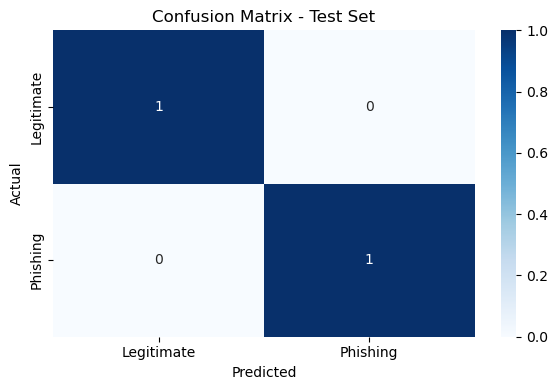

In [29]:
# 1️⃣ Imports
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2️⃣ Model और Tokenizer load करो (pretrained BERT)
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 3️⃣ Example data (अपना dataset यहाँ डालो)
train_texts = ["यह एक सुरक्षित ईमेल है।", "यहाँ क्लिक करो और इनाम पाओ!"]
train_labels = [0, 1]

val_texts = ["आपका खाता सुरक्षित है।", "पासवर्ड रीसेट करने के लिए यहाँ क्लिक करें!"]
val_labels = [0, 1]

test_texts = ["यह एक सुरक्षित ईमेल है।", "यहाँ क्लिक करो और इनाम पाओ!"]
test_labels = [0, 1]

# 4️⃣ Encode data
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

# 5️⃣ Dataset class
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, train_labels)
val_dataset   = EmailDataset(val_encodings, val_labels)
test_dataset  = EmailDataset(test_encodings, test_labels)

# 6️⃣ TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',
    do_eval=True,              # पुरानी versions में evaluation_strategy नहीं होता
    eval_steps=500,            # हर 500 steps पर evaluation
    save_steps=500,
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=500
)

# 7️⃣ Trainer initialize
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

# 8️⃣ Training
trainer.train()

# 9️⃣ Prediction on test set
test_results = trainer.predict(test_dataset)
y_pred = test_results.predictions.argmax(axis=1)
y_true = test_labels

# 🔟 Evaluation metrics
print("Final Test Evaluation Metrics:\n")
print("Accuracy       :", accuracy_score(y_true, y_pred))
print("Precision      :", precision_score(y_true, y_pred))
print("Recall         :", recall_score(y_true, y_pred))
print("F1 Score       :", f1_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Legitimate", "Phishing"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()


In [30]:
from sklearn.metrics import classification_report

y_pred = test_results.predictions.argmax(axis=1)
print(classification_report(test_labels, y_pred, target_names=["Legitimate", "Phishing"]))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         1
    Phishing       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

